In [7]:
import glob
import pandas as pd

csv = glob.glob('/kaggle/input/datasets/kanchana1990/e-commerce-ram-pricing-intelligence-2026/ram_pricing_intelligence_2026.csv', recursive=True)[0]
df = pd.read_csv(csv)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2899 entries, 0 to 2898
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ram_generation  2899 non-null   object 
 1   brand           2895 non-null   object 
 2   seller_id       2899 non-null   object 
 3   condition       2899 non-null   object 
 4   title           2899 non-null   object 
 5   capacity_gb     2863 non-null   float64
 6   bus_speed_mhz   2272 non-null   float64
 7   unit_type       2899 non-null   object 
 8   price           2899 non-null   float64
 9   wasPrice        123 non-null    float64
 10  available       1770 non-null   float64
 11  sold            920 non-null    float64
 12  itemLocation    2899 non-null   object 
 13  lastUpdated     2110 non-null   object 
 14  mpn             1818 non-null   object 
 15  type            2792 non-null   object 
 16  is_bulk_server  2899 non-null   int64  
dtypes: float64(6), int64(1), object(1

# **1. Data validation**

In [19]:
print(f'Number of duplicates: {df.duplicated().sum()}\n')
print(f'Number of unique values in the table: \n\n{df.nunique()}')
df.head()

Number of duplicates: 2

Number of unique values in the table: 

ram_generation       3
brand              149
seller_id         1276
condition            6
title             2821
capacity_gb         21
bus_speed_mhz       31
unit_type            3
price              931
wasPrice           102
available           46
sold               123
itemLocation       855
lastUpdated       1639
mpn               1320
type               139
is_bulk_server       2
dtype: int64


,ram_generation,brand,seller_id,condition,title,capacity_gb,bus_speed_mhz,unit_type,price,wasPrice,available,sold,itemLocation,lastUpdated,mpn,type,is_bulk_server
0,DDR4,SK hynix,Seller_0001,Used,SK Hynix 64GB 4DRx4 PC4-2400T DDR4 ECC Server ...,64.0,2400.0,Single,229.00,NaN,6.0,2.0,"Lakeville, Minnesota, United States",2026-04-24 21:22:14,HMAA8GL7MMR4NUH,DDR4 SDRAM,1
1,DDR4,A-Tech,Seller_0002,New,A-Tech 32GB 2x 16GB PC4-21300 Laptop SODIMM 26...,32.0,2666.0,Dual Kit,231.98,NaN,10.0,1728.0,"Columbus, Ohio, United States",2026-04-20 10:40:28,AT16G2D4S2666ND8N12V,DDR4 SDRAM,0
2,DDR4,Crucial,Seller_0003,Used,16GB Crucial Micron DDR4-2133 PC4-17000 RDIMM ...,16.0,2133.0,Single,57.99,NaN,8.0,28.0,"Las Vegas, Nevada, United States",2026-04-24 20:40:30,"CT16G4RFD4213, CT16G4RFD4213.36FA2, CT16G4RFD4...",DDR4 SDRAM,1
3,DDR4,SK hynix,Seller_0004,Used,SK HYNIX 32GB HMA84GR7MFR4N-UH DDR4-2400 2Rx4 ...,32.0,2400.0,Single,189.99,NaN,10.0,3.0,"Wauconda, Illinois, United States",2026-04-18 08:03:11,HMA84GR7MFR4NUH,ECC RAM,0
4,DDR4,RAM,Seller_0005,Used,Mixed Brand 8GB DDR4 Desktop RAM PC4 UDIMM - C...,8.0,NaN,Single,23.49,NaN,6.0,51.0,"Auburn Hills, Michigan, United States",2026-04-23 08:31:55,NaN,DDR4 SDRAM,0


In [20]:
 df['type'].unique()

array(['DDR4 SDRAM', 'ECC RAM', 'Gaming RAM', 'DDR4 DRAM', 'DDR4 SODIMM',
       'DDR4', 'Server Ram', nan, 'Does not apply', 'DDR4 RDIMM',
       'SODIMM', 'DDR5 SODIMM', 'Laptop RAM', 'DDR3 SDRAM', 'Ram', 'DDR5',
       'Ddr4', '288-Pin DDR5 SDRAM', 'DDR4-2933', 'DDR 4', '8GB Dimm',
       'Laptop Replacement Parts', 'DDR2 SODIMM', 'DDR4 UDIMM',
       '8GB DDR4', 'MEMORY', 'DDR4 SO-DIMM', '1.1V', 'DDR5 SDRAM',
       'DDR4-2666', 'ECC Sodimm RAM', 'DDR5-5600', 'DDR4 Ram 2400Mhz',
       'Memory Ram', 'GDDR5 SDRAM', 'Lenovo Yoga 710-15IKB',
       'DDR4 SO-DIMM SDRAM', 'ddr5 sodimm', 'DDR4 Memory Filler',
       'Memory', 'DDR3L', 'RAM Memory', 'DDR5 288-Pin PC UDIMM',
       '288-Pin PC RAM', 'DDR4 288-Pin PC UDIMM', 'DDR5 UDIMM',
       'Not Available', 'Memory Module', 'DDR4 RAM',
       'Other Consumer Electronics', 'GDDR4 SDRAM', 'Server Memory',
       'DDR4 260-Pin LAPTOP SODIMM', 'DDR4-2400', 'RAM',
       'Internal Memory', 'Regular Type', 'DDR5 SDRAM (UDIMM)',
       'Detai

Removing the 'type' column to optimize dataset cleanliness. 
The column contained highly inconsistent, unstructured, and noisy data (e.g., mixing RAM form factors, brand names, and irrelevant categories like 'Washer & Dryer Parts'). 
Key generation information (DDR4/DDR5) has already been consolidated into the 'ram_generation' column, making 'type' redundant and prone to data quality issues.


In [21]:
df = df.drop(columns=['type'])

In [22]:
# Convert price to numeric, turning non-parseable values into NaN for safe calculation
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Standardize date format for time-series analysis
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'])

# Impute missing brands with 'Unknown' to maintain data integrity
df['brand'] = df['brand'].fillna('Unknown')

# Assume zero sales where data is missing
df['sold'] = df['sold'].fillna(0)

# If 'wasPrice' is missing, assume no discount (original price equals current price)
df['wasPrice'] = df['wasPrice'].fillna(df['price'])

# Fill missing MPNs with 'Unknown' for database consistency
df['mpn'] = df['mpn'].fillna('Unknown')

# Recover missing capacity from listing titles using regex to reduce data loss
df['capacity_gb'] = df['capacity_gb'].fillna(df['title'].str.extract(r'(\d+)\s*[Gg][Bb]')[0].astype(float))

# Fill missing speeds with the median speed of the respective RAM generation to avoid outliers
df['bus_speed_mhz'] = df.groupby('ram_generation')['bus_speed_mhz'].transform(lambda x: x.fillna(x.median()))

# Assume zero availability where stock is undisclosed
df['available'] = df['available'].fillna(0)

# Fill missing update dates with the median timestamp to keep data in a valid temporal range
df['lastUpdated'] = df['lastUpdated'].fillna(df['lastUpdated'].median())

In [23]:
for col in ['ram_generation', 'brand', 'condition', 'unit_type']:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts())


ram_generation (3 unique):
ram_generation
DDR5    1510
DDR4    1387
DDR3       2
Name: count, dtype: int64

brand (150 unique):
brand
BytecRAM                    359
A-Tech                      241
Kingston                    227
Corsair                     224
Samsung                     223
                           ... 
OEM Dell                      1
Mushkin Enhanced              1
Total Micro Technologies      1
Major Brand / Various         1
Xfinity V-Color               1
Name: count, Length: 150, dtype: int64

condition (6 unique):
condition
New                         1560
Used                         859
Open box                     454
Excellent - Refurbished       13
For parts or not working      10
Very Good - Refurbished        3
Name: count, dtype: int64

unit_type (3 unique):
unit_type
Single      1898
Dual Kit     844
Bulk         157
Name: count, dtype: int64


In [24]:
# Consolidate various refurbished sub-categories into a single 'Refurbished' label 
# to improve statistical significance and reduce categorical noise.
df['condition'] = df['condition'].replace({
    'Excellent - Refurbished': 'Refurbished',
    'Very Good - Refurbished': 'Refurbished'
})

# Remove 'DDR3' entries as they represent statistical outliers (only 2 records)
df = df[df['ram_generation'] != 'DDR3']

In [25]:
pd.set_option('display.max_rows', None)
brand_counts = df['brand'].value_counts()
 
print(brand_counts)

brand
BytecRAM                                      359
A-Tech                                        241
Kingston                                      227
Corsair                                       224
Samsung                                       223
G. SKILL                                      190
Crucial                                       173
SK hynix                                      160
RigidRAM                                      108
Major Brand                                   104
Micron                                         99
Team Group                                     65
OWC                                            44
Arch Memory                                    39
Patriot Memory                                 37
G.SKILL                                        32
MB                                             31
Hynix                                          30
Patriot                                        30
Dell                                        

Many brands appear only 1-2 times, which can cause overfitting. I group all rare brands (appearing less than 5 times) into a single 'Other' category

In [26]:
brands_counts = df['brand'].value_counts()
rare_brands = brands_counts[brands_counts < 5].index
df['brand'] = df['brand'].replace(rare_brands, 'Other')

Also many brands had inconsistent naming conventions (different capitalization, abbreviations, etc.)
I create a mapping to standardize all brand names to their correct canonical forms

In [28]:
brand_mapping = {
    # G.Skill
    'G. SKILL': 'G.Skill',
    'G.SKILL': 'G.Skill',
    'G Skill': 'G.Skill',

    # SK Hynix
    'SK hynix': 'SK Hynix',
    'Hynix': 'SK Hynix',
    'HYNIX': 'SK Hynix',

    # Patriot
    'Patriot Memory': 'Patriot',

    # Team Group
    'TeamGroup': 'Team Group',
    'TEAMGROUP': 'Team Group',
    'Team': 'Team Group',
    'Team Group Inc': 'Team Group',

    # Corsair
    'CORSAIR': 'Corsair',

    # Kingston
    'Kingston Technology Corp.': 'Kingston',

    # Other (invalid or irrelevant values)
    'Does not apply': 'Other',
    'MB': 'Other',
    'RAM': 'Other',
}

df['brand'] = df['brand'].replace(brand_mapping)

# **2. Database Normalization**

I applied database normalization to the original dataset. By separating the data into listings, products, and sellers tables, I minimized data redundancy and created a scalable architecture suitable for complex analytical queries.

In [29]:
#Table 1 - Product

product_cols = ['ram_generation', 'brand', 'capacity_gb',
                'bus_speed_mhz', 'unit_type',
                'mpn', 'is_bulk_server']
products = df[product_cols].drop_duplicates().reset_index(drop=True)
products['product_id'] = products.index + 1

print(products.head())

  ram_generation     brand  capacity_gb  bus_speed_mhz unit_type  \
0           DDR4  SK Hynix         64.0         2400.0    Single   
1           DDR4    A-Tech         32.0         2666.0  Dual Kit   
2           DDR4   Crucial         16.0         2133.0    Single   
3           DDR4  SK Hynix         32.0         2400.0    Single   
4           DDR4     Other          8.0         2666.0    Single   

                                                 mpn  is_bulk_server  \
0                                    HMAA8GL7MMR4NUH               1   
1                               AT16G2D4S2666ND8N12V               0   
2  CT16G4RFD4213, CT16G4RFD4213.36FA2, CT16G4RFD4...               1   
3                                    HMA84GR7MFR4NUH               0   
4                                            Unknown               0   

   product_id  
0           1  
1           2  
2           3  
3           4  
4           5  


I identified that a single product could have multiple manufacturer part numbers (MPNs). 
I decided to check how many comma-separated words one row can contain in this column

In [30]:
print(products['mpn'].str.split(',').str.len().value_counts())

mpn
1     1705
2      132
3       18
4        7
5        6
6        4
9        1
8        1
11       1
7        1
Name: count, dtype: int64


MPN contains multiple comma-separated values (up to 7 variants per product).
We create a separate table to split them into individual rows for better analysis

In [31]:
#Table 2 - MPN
mpn_table = products[['product_id', 'mpn']].copy()

mpn_table = mpn_table.dropna(subset=['mpn'])

mpn_table = mpn_table.assign(mpn=mpn_table['mpn'].str.split(',')).explode('mpn')

mpn_table['mpn'] = mpn_table['mpn'].str.strip()

mpn_table = mpn_table.reset_index(drop=True)

print(mpn_table.head(10))

   product_id                   mpn
0           1       HMAA8GL7MMR4NUH
1           2  AT16G2D4S2666ND8N12V
2           3         CT16G4RFD4213
3           3   CT16G4RFD4213.36FA2
4           3   CT16G4RFD4213.36FB1
5           4       HMA84GR7MFR4NUH
6           5               Unknown
7           6               Unknown
8           7       16 GB PC4-17000
9           8               Unknown


In [32]:
# Table 3 - Sellers
sellers_cols = ['product_id', 'seller_id', 'itemLocation']

sellers = df[['seller_id', 'itemLocation']].copy()

sellers = df.merge(products[['product_id'] + product_cols],
                   on=product_cols,
                   how='left')

sellers = sellers[['product_id', 'seller_id', 'itemLocation']]
 
print(sellers[['product_id', 'seller_id', 'itemLocation']].head())

   product_id    seller_id                           itemLocation
0           1  Seller_0001    Lakeville, Minnesota, United States
1           2  Seller_0002          Columbus, Ohio, United States
2           3  Seller_0003       Las Vegas, Nevada, United States
3           4  Seller_0004      Wauconda, Illinois, United States
4           5  Seller_0005  Auburn Hills, Michigan, United States


Check how many location components (city, state, country) are in each row.
This helps us understand the data structure before splitting

In [33]:
print(sellers['itemLocation'].str.split(',').str.len().value_counts())

itemLocation
3    2772
2     123
4       1
5       1
Name: count, dtype: int64


In [34]:
# Parse location string into separate city, state, and country components

def parse_location(location):
    if pd.isna(location) or location == '':
        return pd.Series({'city': None, 'state': None, 'country': None})

    parts = [p.strip() for p in str(location).split(',')]

    if len(parts) == 1:
        return pd.Series({'city': None, 'state': None, 'country': parts[0]})

    elif len(parts) == 2:
        return pd.Series({'city': parts[0], 'state': None, 'country': parts[1]})

    elif len(parts) == 3:
        return pd.Series({'city': parts[0], 'state': parts[1], 'country': parts[2]})

    else:
        return pd.Series({'city': parts[0], 'state': parts[-2], 'country': parts[-1]})


location_parsed = sellers['itemLocation'].apply(parse_location)

sellers = pd.concat([sellers, location_parsed], axis=1)
sellers = sellers.drop(columns=['itemLocation'])

In [35]:
 print(sellers.head(10))

   product_id    seller_id          city           state        country
0           1  Seller_0001     Lakeville       Minnesota  United States
1           2  Seller_0002      Columbus            Ohio  United States
2           3  Seller_0003     Las Vegas          Nevada  United States
3           4  Seller_0004      Wauconda        Illinois  United States
4           5  Seller_0005  Auburn Hills        Michigan  United States
5           6  Seller_0006     Nashville       Tennessee  United States
6           7  Seller_0007  Indianapolis         Indiana  United States
7           8  Seller_0008    Orangeburg  South Carolina  United States
8           9  Seller_0009       Hialeah         Florida  United States
9          10  Seller_0010     Deer Park        New York  United States


In [36]:
# Table 4 - Listings

listings = df[product_cols + ['title', 'condition', 'price', 'wasPrice',
                              'available', 'sold', 'lastUpdated', 'seller_id']].merge(
    products[['product_id'] + product_cols],
    on=product_cols,
    how='left'
)

listings = listings[['product_id', 'title', 'condition', 'price', 'wasPrice',
                     'available', 'sold', 'lastUpdated', 'seller_id']]

print(listings.head())

   product_id                                              title condition  \
0           1  SK Hynix 64GB 4DRx4 PC4-2400T DDR4 ECC Server ...      Used   
1           2  A-Tech 32GB 2x 16GB PC4-21300 Laptop SODIMM 26...       New   
2           3  16GB Crucial Micron DDR4-2133 PC4-17000 RDIMM ...      Used   
3           4  SK HYNIX 32GB HMA84GR7MFR4N-UH DDR4-2400 2Rx4 ...      Used   
4           5  Mixed Brand 8GB DDR4 Desktop RAM PC4 UDIMM - C...      Used   

    price  wasPrice  available    sold         lastUpdated    seller_id  
0  229.00    229.00        6.0     2.0 2026-04-24 21:22:14  Seller_0001  
1  231.98    231.98       10.0  1728.0 2026-04-20 10:40:28  Seller_0002  
2   57.99     57.99        8.0    28.0 2026-04-24 20:40:30  Seller_0003  
3  189.99    189.99       10.0     3.0 2026-04-18 08:03:11  Seller_0004  
4   23.49     23.49        6.0    51.0 2026-04-23 08:31:55  Seller_0005  


# **3. Analysis of price per GB by brands and generations of RAM**

In [45]:
import sqlite3

conn = sqlite3.connect(':memory:') 

products.to_sql('products', conn, if_exists='replace', index=False)
listings.to_sql('listings', conn, if_exists='replace', index=False)

result = pd.read_sql_query("""
    SELECT 
        p.brand, 
        p.ram_generation,
        p.capacity_gb,
        ROUND(AVG(l.price / p.capacity_gb), 2) AS avg_price_per_gb
    FROM products p
    JOIN listings l ON p.product_id = l.product_id
    GROUP BY p.brand, p.ram_generation
    ORDER BY avg_price_per_gb
""", conn)

conn.close()
print(result)


            brand ram_generation  capacity_gb  avg_price_per_gb
0           Intel           DDR4        256.0              1.83
1      Team Group           DDR4         16.0              2.50
2            GeIL           DDR5        532.0              2.95
3            GeIL           DDR4         16.0              3.72
4           Axiom           DDR4          8.0              3.75
5           ADATA           DDR4         16.0              4.34
6         Ramaxel           DDR4          8.0              4.43
7        Kingston           DDR4         32.0              4.74
8             XPG           DDR4         16.0              5.19
9         Corsair           DDR4         32.0              5.91
10          Apple           DDR4         32.0              5.99
11         Micron           DDR4         64.0              6.32
12       SK Hynix           DDR4         64.0              6.36
13             HP           DDR4          4.0              6.39
14        G.Skill           DDR4        

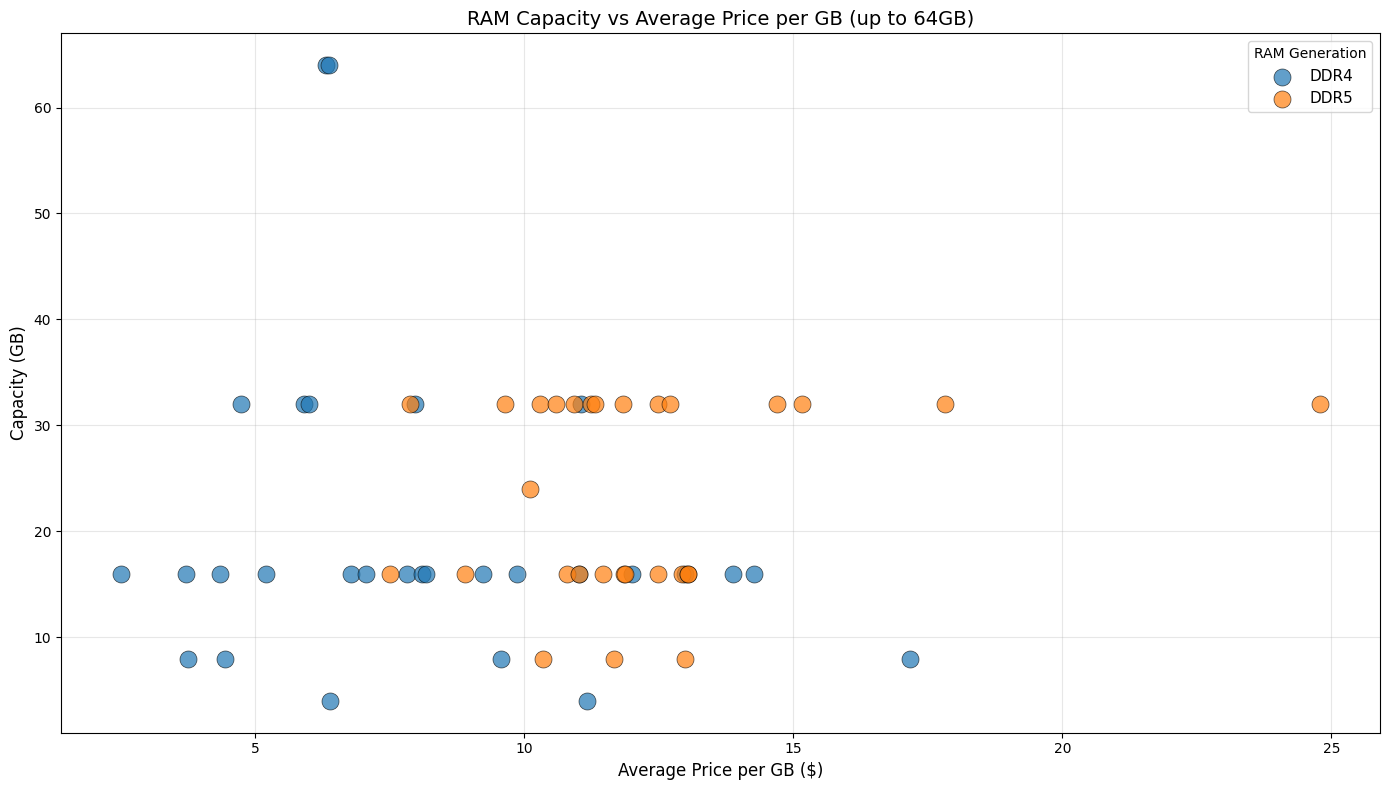

In [63]:
import matplotlib.pyplot as plt

result_filtered = result[result['capacity_gb'] <= 64]

plt.figure(figsize=(14, 8))

for generation in result_filtered['ram_generation'].unique():
    gen_data = result_filtered[result_filtered['ram_generation'] == generation]
    plt.scatter(gen_data['avg_price_per_gb'], gen_data['capacity_gb'],
                label=generation, alpha=0.7, s=150, edgecolors='black', linewidth=0.5)

plt.xlabel('Average Price per GB ($)', fontsize=12)
plt.ylabel('Capacity (GB)', fontsize=12)
plt.title('RAM Capacity vs Average Price per GB (up to 64GB)', fontsize=14)
plt.legend(title='RAM Generation', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
 
plt.show()

The average price of the new generation is higher than that of the previous one

# **4. DDR5 vs DDR4: Segment Analysis**


In [64]:
import sqlite3

conn = sqlite3.connect(':memory:') 

products.to_sql('products', conn, if_exists='replace', index=False)
listings.to_sql('listings', conn, if_exists='replace', index=False)

comparison_DDR = pd.read_sql_query("""
    SELECT p.ram_generation,
       CASE 
          WHEN p.capacity_gb <= 8 THEN 'Entry-Level'
          WHEN p.capacity_gb <= 32 THEN 'Mainstream'
          WHEN p.capacity_gb <= 96 THEN 'Pro/Enthusiast'
          ELSE 'Enterprise'
          END AS capacity_segment,
       ROUND(AVG(bus_speed_mhz), 1) AS avg_speed,
	   ROUND(AVG(l.price), 2) AS avg_price,
	   ROUND(AVG(l.price / bus_speed_mhz), 4) AS avg_price_per_mhz,
	   SUM(l.sold) AS total_sold
FROM listings l
JOIN products p ON p.product_id = l.product_id
WHERE capacity_gb NOT IN (38)
GROUP BY p.ram_generation, capacity_segment
""", conn)

conn.close()
print(comparison_DDR )

  ram_generation capacity_segment  avg_speed  avg_price  avg_price_per_mhz  \
0           DDR4       Enterprise     2769.6    1479.12             0.5446   
1           DDR4      Entry-Level     2640.1      65.99             0.0251   
2           DDR4       Mainstream     2743.4     159.71             0.0585   
3           DDR4   Pro/Enthusiast     2794.9     723.26             0.2655   
4           DDR5       Enterprise     5714.3    2529.23             0.4450   
5           DDR5      Entry-Level     5441.0     119.88             0.0221   
6           DDR5       Mainstream     5650.2     314.11             0.0554   
7           DDR5   Pro/Enthusiast     6031.7     645.00             0.1082   

   total_sold  
0      1056.0  
1     13296.0  
2     11243.0  
3       215.0  
4       596.0  
5      1944.0  
6      5107.0  
7      1644.0  


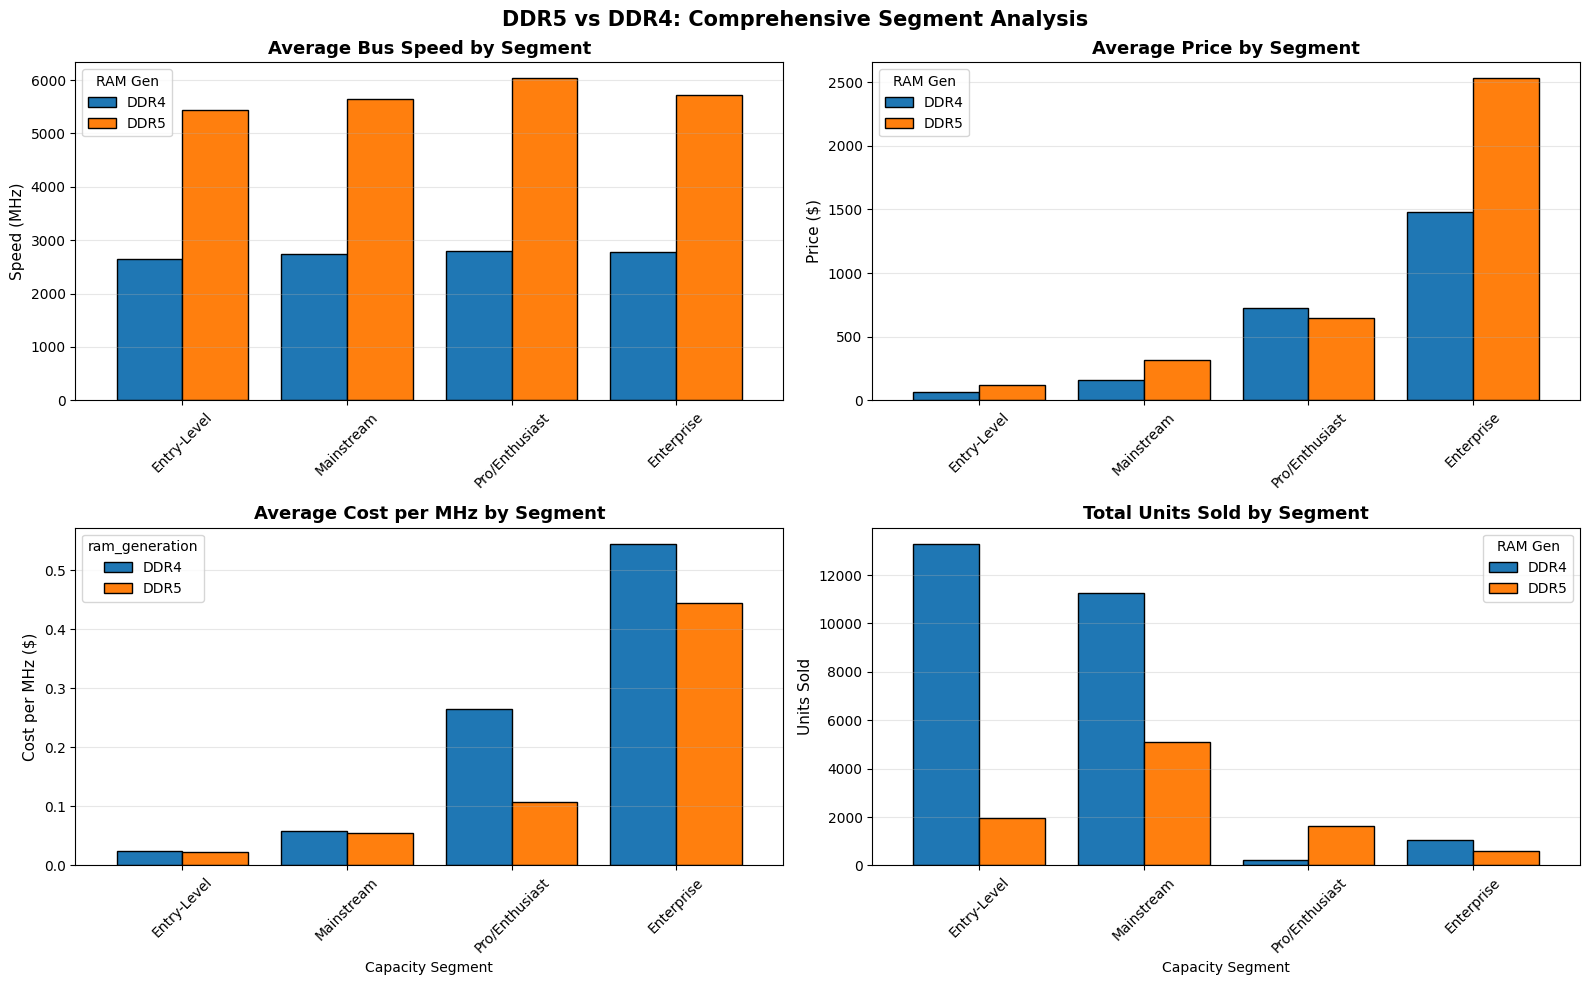

In [72]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

segments_order = ['Entry-Level', 'Mainstream', 'Pro/Enthusiast', 'Enterprise']
comparison_DDR['capacity_segment'] = pd.Categorical(comparison_DDR['capacity_segment'], 
                                                       categories=segments_order, 
                                                       ordered=True)
comparison_DDR = comparison_DDR.sort_values('capacity_segment')

# Graph 1: Average speed
pivot_speed = comparison_DDR.pivot(index='capacity_segment', columns='ram_generation', values='avg_speed')
pivot_speed.plot(kind='bar', ax=axes[0, 0], color=['#1f77b4', '#ff7f0e'], width=0.8, edgecolor='black')
axes[0, 0].set_title('Average Bus Speed by Segment', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Speed (MHz)', fontsize=11)
axes[0, 0].set_xlabel('')
axes[0, 0].legend(title='RAM Gen', fontsize=10)
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].tick_params(axis='x', rotation=45)

# Graph 2: Average price
pivot_price = comparison_DDR.pivot(index='capacity_segment', columns='ram_generation', values='avg_price')
pivot_price.plot(kind='bar', ax=axes[0, 1], color=['#1f77b4', '#ff7f0e'], width=0.8, edgecolor='black')
axes[0, 1].set_title('Average Price by Segment', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Price ($)', fontsize=11)
axes[0, 1].set_xlabel('')
axes[0, 1].legend(title='RAM Gen', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].tick_params(axis='x', rotation=45)

# Graph 3: Cost per MHz
pivot_per_mhz = comparison_DDR.pivot(index='capacity_segment', columns='ram_generation', values='avg_price_per_mhz')
pivot_per_mhz.plot(kind='bar', ax=axes[1, 0], color=['#1f77b4', '#ff7f0e'], width=0.8, edgecolor='black')
axes[1, 0].set_title('Average Cost per MHz by Segment', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Cost per MHz ($)', fontsize=11)
axes[1, 0].set_xlabel('Capacity Segment')
axes[0, 0].legend(title='RAM Gen', fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=45)

# Graph 4: Sales
pivot_sold = comparison_DDR.pivot(index='capacity_segment', columns='ram_generation', values='total_sold')
pivot_sold.plot(kind='bar', ax=axes[1, 1], color=['#1f77b4', '#ff7f0e'], width=0.8, edgecolor='black')
axes[1, 1].set_title('Total Units Sold by Segment', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Units Sold', fontsize=11)
axes[1, 1].set_xlabel('Capacity Segment')
axes[1, 1].legend(title='RAM Gen', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('DDR5 vs DDR4: Comprehensive Segment Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.show()

**Key Findings**

**Performance:**

* DDR5 is faster than DDR4 (5,709 vs 2,687 MHz average)
* Speed advantage consistent across all segments

**Pricing:**

* DDR5 costs 72% more on average (616 vs 357)
* DDR5 surprisingly cheaper in average in Pro/Enthusiast

**Value (Cost per MHz):**

* DDR5 cheaper in all segments

**Market Share:**

* DDR4 dominates: 79.4% of units sold (35,754 vs 9,291)
* Entry-level is largest segment for DDR4
* DDR5 gaining strongest traction in Mainstream category

# **5. Sales by product condition and RAM generation**

In [73]:
conn = sqlite3.connect(':memory:') 

products.to_sql('products', conn, if_exists='replace', index=False)
listings.to_sql('listings', conn, if_exists='replace', index=False)

condition_perfomance = pd.read_sql_query("""
    SELECT 
    l.condition,
	p.ram_generation,
    COUNT(*) AS listing_count,
    SUM(l.sold) AS total_sold,
    ROUND(AVG(l.price), 2) AS avg_price
FROM listings l
JOIN products p ON p.product_id = l.product_id
GROUP BY l.condition, p.ram_generation
ORDER BY total_sold DESC
""", conn)

conn.close()
print(condition_perfomance )

                  condition ram_generation  listing_count  total_sold  \
0                      Used           DDR4            369     14843.0   
1                       New           DDR4            855      7441.0   
2                       New           DDR5            704      6863.0   
3                  Open box           DDR4            155      3451.0   
4                      Used           DDR5            489      2645.0   
5                  Open box           DDR5            299       979.0   
6               Refurbished           DDR4              7       124.0   
7               Refurbished           DDR5              9        90.0   
8  For parts or not working           DDR5              9        22.0   
9  For parts or not working           DDR4              1         0.0   

   avg_price  
0     138.61  
1     139.71  
2     421.82  
3      95.32  
4     333.91  
5     420.00  
6      88.14  
7     260.07  
8     165.88  
9      45.00  


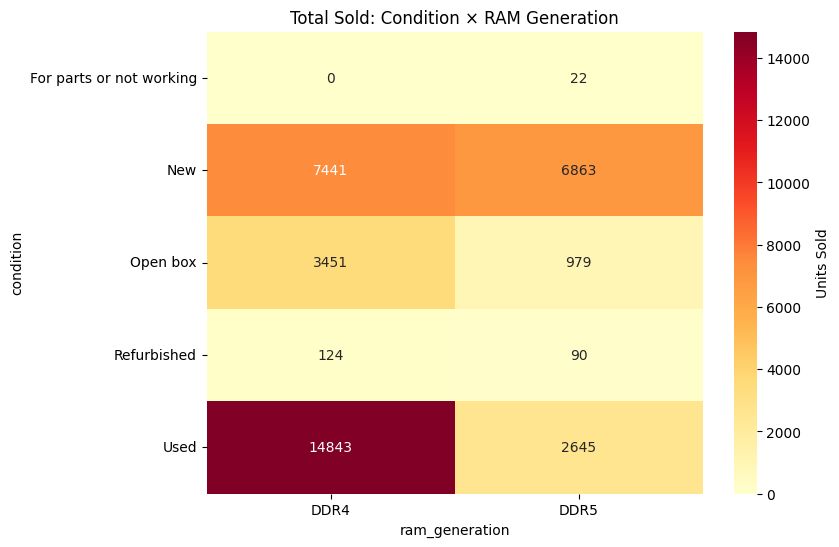

In [74]:
import seaborn as sns

# Для total_sold
pivot_sold = condition_perfomance.pivot(index='condition', columns='ram_generation', values='total_sold')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_sold, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Units Sold'})
plt.title('Total Sold: Condition × RAM Generation')
plt.show()

- **DDR4**: Maximum sales volume comes from used goods 
(14,843 units), indicating high demand for available memory
- **DDR5**: Buyers prefer new modules (6,863 pcs.), 
despite the significantly higher price.
- Refurbished and non-performing products have a minimum sales volume

# **6.Market Segment Performance: Enterprise vs Consumer**

In [83]:
for col in listings.columns:
    if 'period' in str(listings[col].dtype).lower():
        listings[col] = listings[col].astype(str)

conn = sqlite3.connect(':memory:') 

products.to_sql('products', conn, if_exists='replace', index=False)
listings.to_sql('listings', conn, if_exists='replace', index=False)

market_segment = pd.read_sql_query("""
    SELECT 
    CASE 
        WHEN p.is_bulk_server = 1 THEN 'Enterprise'
        ELSE 'Consumer' 
    END AS type_market,
    COUNT(*) AS listing_count,
    SUM(l.sold) AS total_sold,
    ROUND(AVG(l.price), 2) AS avg_price
FROM listings l
JOIN products p ON p.product_id = l.product_id
GROUP BY type_market
""", conn)

conn.close()
print(market_segment)

  type_market  listing_count  total_sold  avg_price
0    Consumer           2662     27123.0     232.03
1  Enterprise            235      9335.0     672.49


Direct comparison of segments is difficult due to significant differences in scale:
- Consumer segment has **11  more listings** and **almost 3x more sales**
- Enterprise products are **almost 3x times more expensive** ( 672 vs  232)
- Different buyers, different needs: mass demand (Consumer) 
vs specialized demand (Enterprise servers)


 Normalized Metrics:

  type_market  sold_per_listing  avg_price
0    Consumer         10.188956     232.03
1  Enterprise         39.723404     672.49


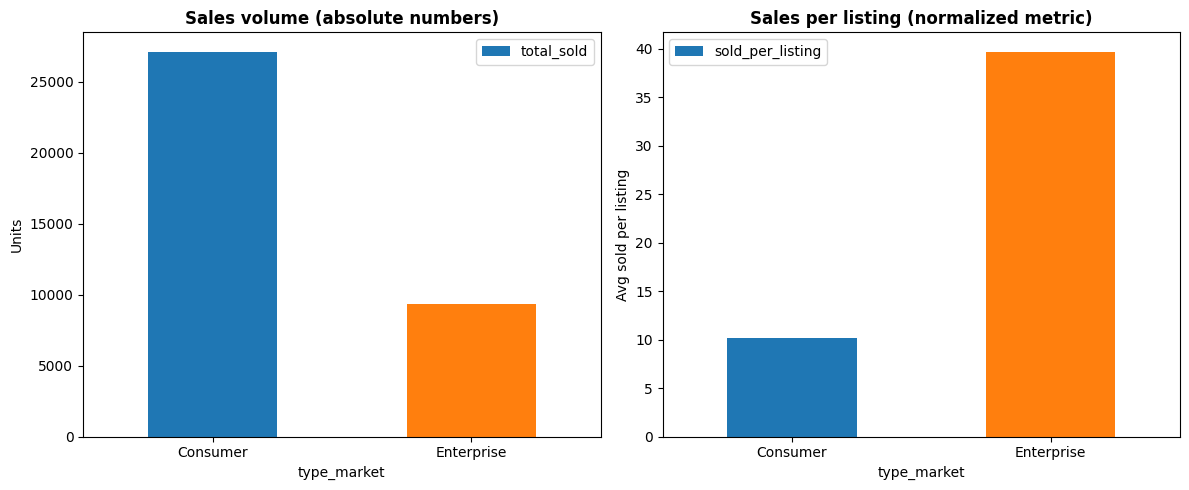

In [100]:
market_segment['sold_per_listing'] = market_segment['total_sold'] / market_segment['listing_count']

print("\n Normalized Metrics:\n")
print(market_segment[['type_market', 'sold_per_listing', 'avg_price']])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sales volume (absolute numbers)
market_segment.plot(x='type_market', y='total_sold', kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Sales volume (absolute numbers)', fontweight='bold')
axes[0].set_ylabel('Units')
axes[0].tick_params(axis='x', rotation=0)
 
 
# Sales per listing (normalized metric)
market_segment.plot(x='type_market', y='sold_per_listing', kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Sales per listing (normalized metric)', fontweight='bold')
axes[1].set_ylabel('Avg sold per listing')

plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

Although Consumer has more sales overall, Enterprise products sell more actively. This is evidenced by the metric number of pieces sold per listing (**almost 40 pieces/listing** in Enterprise versus **10 pieces/listing** in Consumer)

# **7.Top cheapest brands in each generation**

In [107]:
conn = sqlite3.connect(':memory:') 

products.to_sql('products', conn, if_exists='replace', index=False)
listings.to_sql('listings', conn, if_exists='replace', index=False)

avg_price_per_gb_br = pd.read_sql_query("""
SELECT 
    p.brand, 
    p.ram_generation,
    ROUND(AVG(l.price / p.capacity_gb), 2) AS avg_price_per_gb
FROM products p
JOIN listings l ON p.product_id = l.product_id
GROUP BY p.brand, p.ram_generation
ORDER BY avg_price_per_gb
""", conn)

conn.close()

print(avg_price_per_gb_br)

            brand ram_generation  avg_price_per_gb
0           Intel           DDR4              1.83
1      Team Group           DDR4              2.50
2            GeIL           DDR5              2.95
3            GeIL           DDR4              3.72
4           Axiom           DDR4              3.75
5           ADATA           DDR4              4.34
6         Ramaxel           DDR4              4.43
7        Kingston           DDR4              4.74
8             XPG           DDR4              5.19
9         Corsair           DDR4              5.91
10          Apple           DDR4              5.99
11         Micron           DDR4              6.32
12       SK Hynix           DDR4              6.36
13             HP           DDR4              6.39
14        G.Skill           DDR4              6.77
15        Crucial           DDR4              7.06
16        Patriot           DDR4              7.08
17    Arch Memory           DDR5              7.50
18    Major Brand           DDR

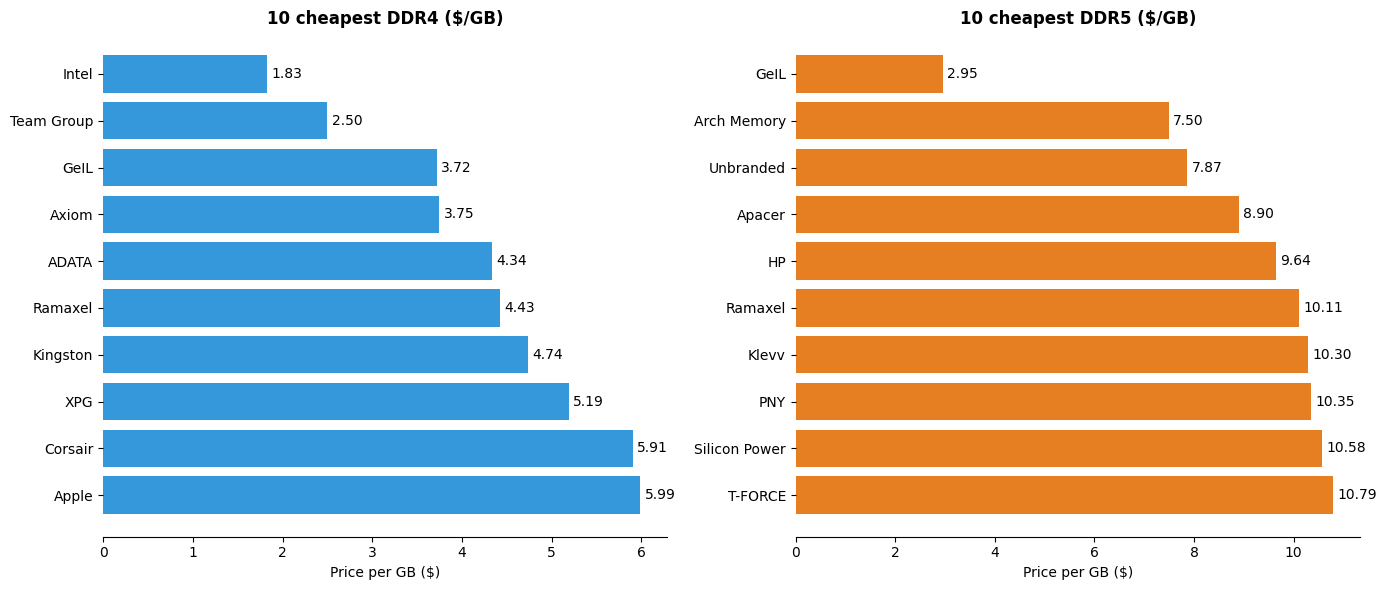

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ddr4 = avg_price_per_gb_br[avg_price_per_gb_br['ram_generation'] == 'DDR4'].nsmallest(10, 'avg_price_per_gb')
ddr5 = avg_price_per_gb_br[avg_price_per_gb_br['ram_generation'] == 'DDR5'].nsmallest(10, 'avg_price_per_gb')

bars0 = axes[0].barh(ddr4['brand'], ddr4['avg_price_per_gb'])
axes[0].barh(ddr4['brand'], ddr4['avg_price_per_gb'], color='#3498db')
axes[0].set_title('10 cheapest DDR4 ($/GB)', fontweight='bold')
axes[0].set_xlabel('Price per GB ($)')
axes[0].invert_yaxis()
axes[0].bar_label(bars0, padding=3, fmt='%.2f')
axes[0].spines[['top', 'right', 'left']].set_visible(False)

bars1 = axes[1].barh(ddr5['brand'], ddr5['avg_price_per_gb'])
axes[1].barh(ddr5['brand'], ddr5['avg_price_per_gb'], color='#e67e22')
axes[1].set_title('10 cheapest DDR5 ($/GB)', fontweight='bold')
axes[1].set_xlabel('Price per GB ($)')
axes[1].invert_yaxis()
axes[1].bar_label(bars1, padding=3, fmt='%.2f')
axes[1].spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.show()